# Week26 - Model Comparison and Final Project Summary

## Goal
Compare Logistic Regression and Random Forest models and summarize the final Credit Risk Analysis project.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
clean_df = pd.read_csv('credit_risk_cleaned.csv')

clean_df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
1,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
2,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
3,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
4,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2


In [3]:
model_df = clean_df[[
    'person_age',
    'person_income',
    'person_emp_length',
    'loan_amnt',
    'loan_int_rate',
    'loan_percent_income',
    'cb_person_cred_hist_length',
    'loan_status'
]]

model_df.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,loan_status
0,21,9600,5.0,1000,11.14,0.10,2,0
1,25,9600,1.0,5500,12.87,0.57,3,1
2,23,65500,4.0,35000,15.23,0.53,2,1
3,24,54400,8.0,35000,14.27,0.55,4,1
4,21,9900,2.0,2500,7.14,0.25,2,1


In [4]:
X = model_df.drop('loan_status', axis=1)

y = model_df['loan_status']

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [6]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [7]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [8]:
y_pred_log = log_model.predict(X_test)

y_pred_rf = rf_model.predict(X_test)

In [9]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [10]:
model_comparison = pd.DataFrame({
    'model': ['Logistic Regression', 'Random Forest'],
    'accuracy': [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf)
    ],
    'precision_default_class': [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_rf)
    ],
    'recall_default_class': [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_rf)
    ],
    'f1_default_class': [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_rf)
    ]
})

model_comparison

,model,accuracy,precision_default_class,recall_default_class,f1_default_class
0,Logistic Regression,0.805833,0.754209,0.158192,0.261529
1,Random Forest,0.880430,0.779631,0.627119,0.695108


In [11]:
model_comparison.to_csv('model_comparison.csv', index=False)

## Model Comparison Insight

This table compares Logistic Regression and Random Forest using accuracy, precision, recall, and F1-score.

Random Forest outperformed Logistic Regression across all evaluation metrics. Most importantly, recall increased from 15.8% to 62.7%, meaning the model identified a much larger proportion of actual default borrowers.

Since detecting default borrowers is a key objective in credit risk analysis, Random Forest was selected as the final model.

In [12]:
comparison_long = model_comparison.melt(
    id_vars='model',
    value_vars=[
        'accuracy',
        'precision_default_class',
        'recall_default_class',
        'f1_default_class'
    ],
    var_name='metric',
    value_name='score'
)

comparison_long

,model,metric,score
0,Logistic Regression,accuracy,0.805833
1,Random Forest,accuracy,0.880430
2,Logistic Regression,precision_default_class,0.754209
3,Random Forest,precision_default_class,0.779631
4,Logistic Regression,recall_default_class,0.158192
5,Random Forest,recall_default_class,0.627119
6,Logistic Regression,f1_default_class,0.261529
7,Random Forest,f1_default_class,0.695108


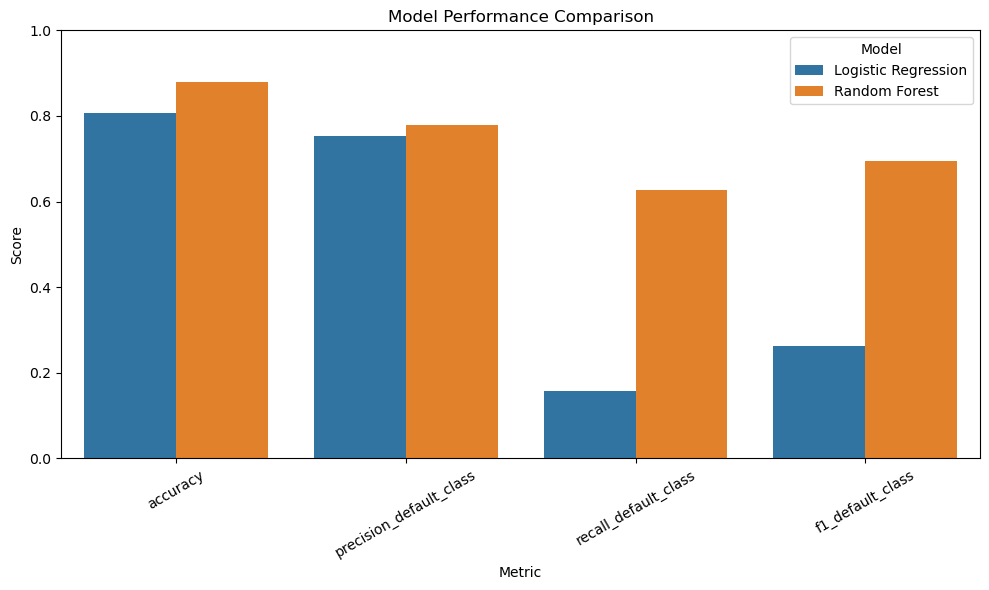

In [14]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x='metric',
    y='score',
    hue='model',
    data=comparison_long
)

plt.title('Model Performance Comparison')
plt.xlabel('Metric')
plt.ylabel('Score')
plt.xticks(rotation=30)
plt.ylim(0, 1)
plt.legend(title='Model')

plt.tight_layout()

plt.savefig('model_comparison_barplot.png', bbox_inches='tight')

plt.show()

## Model Comparison Chart Insight

The chart compares Logistic Regression and Random Forest across four evaluation metrics: accuracy, precision, recall, and F1-score.

Random Forest outperformed Logistic Regression on all metrics. The largest improvement was in recall (62.7% vs. 15.8%), meaning it identified significantly more default borrowers.

Since detecting high-risk borrowers is the primary objective in credit risk analysis, Random Forest was selected as the final model.

final_summary = """
# Final Project Summary

## Project Objective
The objective of this project was to analyze credit risk data and identify factors associated with loan default.

## Work Completed
- Data cleaning and quality assessment
- Target variable analysis
- Exploratory data analysis (EDA)
- Risk segmentation analysis
- Tableau dashboard development
- Logistic Regression modeling
- Random Forest modeling
- Model performance comparison

## Key Business Insights
- Loan grade was one of the strongest predictors of default risk.
- Borrowers with a higher loan burden showed higher default rates.
- Previous default history was associated with increased risk.
- Renters exhibited higher default rates than homeowners.

## Model Insight
Both Logistic Regression and Random Forest were evaluated. While Logistic Regression offers better interpretability, Random Forest achieved stronger overall performance.

Most importantly, Random Forest improved recall from 15.8% to 62.7%, allowing the model to identify substantially more high-risk borrowers.

## Business Recommendation
Lenders should apply closer monitoring and stricter risk controls for borrowers with:
- Lower loan grades
- Higher loan burden ratios
- Previous default history
- Rental housing status

These factors can support more effective credit risk assessment and decision-making.
"""

with open('final_project_summary.md', 'w') as f:
    f.write(final_summary)